# Figures for Laurianne's NAMS 2025 presentation

Prepared by: Molly Dougher

Adapted from: Xinhong Liu xliu27@nd.edu

### Import library

In [1]:
from utility import *

future: the set contained only NumericConstant and _PythonCallbackFunctionID,
and provided no meaningful value to clients or walkers.  Users should likely
handle these types in the same manner as immutable Params.  (deprecated in
6.7.2) (called from <frozen importlib._bootstrap>:241)
'_BlockData'.  The class '_BlockData' has been renamed to 'BlockData'.
(deprecated in 6.7.2) (called from /opt/anaconda3/envs/dynamic-
diafiltration/lib/python3.11/site-packages/idaes/core/base/process_base.py:78)
from '_GeneralExpressionData'.  The class '_GeneralExpressionData' has been
renamed to 'ExpressionData'.  (deprecated in 6.7.2) (called from
/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-
packages/idaes/core/base/var_like_expression.py:31)


# NF90 (DATA1)
## Concentrations: Figure 2C-D

In [2]:
from DATA1_matlab.diafiltration_plots import plot_sim_comparison as plot_sim_comparisonDATA1


Loading data file = DATA1_matlab/data/data_stru-dataset511.12.mat 


Loading data file = DATA1_matlab/data/511.12 concpolar/fit_stru.mat 



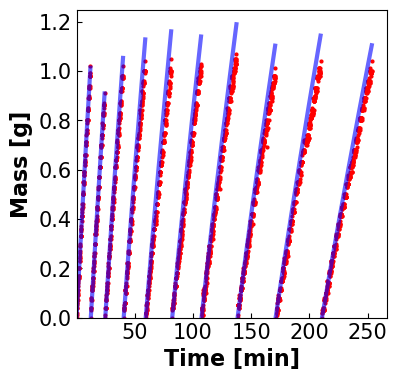

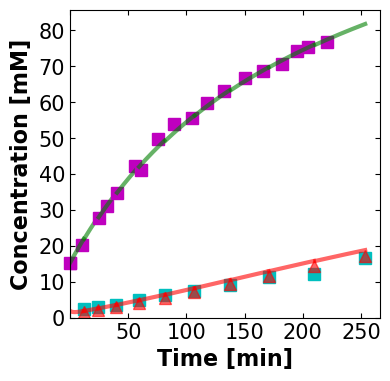

In [3]:
# pull the data from DATA1_matlab/DiafiltrationPaperPlots.ipynb
### Diafiltration
#### M1(conctration polarization, continuous retentate)
# Figure 2, 5, 6, S3, S4
data_stru90 = loadmat('DATA1_matlab/data/data_stru-dataset511.12.mat')['data_stru']
fit_stru90 = loadmat('DATA1_matlab/data/511.12 concpolar/fit_stru.mat')['fit_stru']
plot_sim_comparisonDATA1(data_stru90,fit_stru90,plot_pred=True,cond=True,lg=False)

## Interfacial concentrations

In [4]:
sim_stru90 = fit_stru90["sim_stru"]

In [5]:
cF_exp_90 = {}
cF_exp_index_90 = {}

for vial in range(data_stru90['data_config']['n']):
        cF_exp_90[vial] = [x for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x)!='nan']
        cF_exp_index_90[vial] = [data_stru90["data_raw"][vial]['cF_exp'].index(x) for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x)!='nan']

print(cF_exp_90)
print(len(cF_exp_90))
print(cF_exp_index_90)
print(len(cF_exp_index_90))

cF_avg = []
for vial, conc in cF_exp_90.items():
        cF_avg.append(np.average(conc))

print(cF_avg)

{0: [15.20517956, 20.17925714], 1: [], 2: [27.74228235, 31.0364], 3: [34.73451321, 42.10616744], 4: [41.21821818, 49.70306667], 5: [53.94549091, 55.5364], 6: [59.79315676, 63.0364], 7: [66.67276364, 68.6614], 8: [70.77833548, 74.22284068, 75.4501931], 9: [76.72061053]}
10
{0: [2, 126], 1: [], 2: [0, 90], 3: [0, 180], 4: [20, 193], 5: [86, 270], 6: [129, 300], 7: [146, 326], 8: [134, 284, 404], 9: [116]}
10
[17.69221835, nan, 29.389341175, 38.420340325, 45.460642425, 54.740945455, 61.41477838, 67.66708181999999, 73.48378975333334, 76.72061053]


/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [34]:
for vial in sim_stru90:
    for var, val in vial.items():
        print(var)
        print(val)

time
[370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 985, 990, 995, 1000, 1005, 1010, 1015, 1020, 1025, 1030, 1035, 1040, 1045, 1050, 1055, 1060, 1065, 1070, 1075, 1080, 1085]
cF
[15.20517956, 15.255525697828705, 15.30581000885246, 15.356033297318026, 15.406196340587751, 15.456299890101391, 15.506344672314373, 15.55633138963366, 15.606260721336648, 15.656133324371995, 15.70594983420232, 15.755710865592919, 15.805417013351075, 15

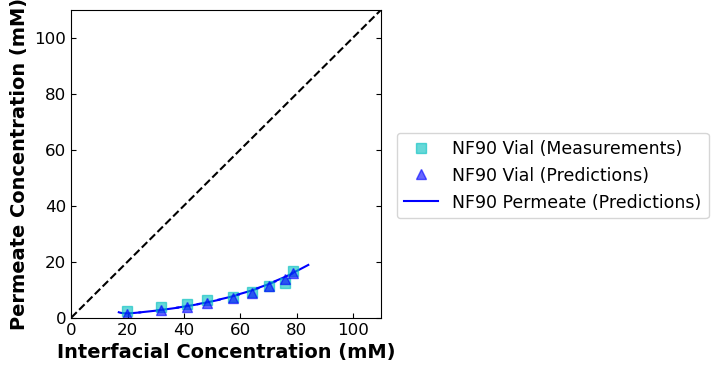

In [46]:
import csv

k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)
cIn_sim = []
fig = plt.figure(figsize=(4,4))
x_data_nf90_perm_predict = []
y_data_nf90_perm_predict = []
x_data_nf90_vial_predict = []
y_data_nf90_vial_predict = []
x_data_nf90_vial_meas = []
y_data_nf90_vial_meas = []

for vial in range(data_stru90['data_config']['n']):
    # calculate simulated water flux per vial
    vial_dmdt_sim = (sim_stru90[vial]["mV"][-1] - sim_stru90[vial]["mV"][0]) / (sim_stru90[vial]["time"][-1] - sim_stru90[vial]["time"][0])
    vial_water_flux_sim = (1/4.1)*vial_dmdt_sim # cm3/cm2/s
    # calculate simulated cIn
    for value in range(len(sim_stru90[vial]["time"])):
        cIn_sim.append((sim_stru90[vial]['cF'][value]-sim_stru90[vial]['cH'][value])*np.exp(vial_water_flux_sim/k)+sim_stru90[vial]['cH'][value])

    # calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    
    # permeate predictions
    plt.plot(cIn_sim,sim_stru90[vial]["cH"],'b-',linewidth=1.5)
    for i in cIn_sim:
        x_data_nf90_perm_predict.append(i)
    for i in sim_stru90[vial]["cH"]:
        y_data_nf90_perm_predict.append(i)

    # vial measurements, plot at the bulk cIn,exp
    plt.plot(cIn_exp,data_stru90['data_raw'][vial]['cV_avg'],'cs',markersize=7,alpha=0.6)
    x_data_nf90_vial_predict.append(cIn_exp)
    y_data_nf90_vial_predict.append(data_stru90['data_raw'][vial]['cV_avg'])

    # vial predictions, plot the bulk predicted cV and the same cIn as exp
    f = interpolate.interp1d(cIn_sim, sim_stru90[vial]['cV'])
    plt.plot(cIn_exp,f(cIn_exp),'b^',markersize=7, alpha=0.6)
    x_data_nf90_vial_meas.append(cIn_exp)
    y_data_nf90_vial_meas.append(f(cIn_exp))
    
    cIn_sim = []


plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,label='NF90 Vial (Measurements)', alpha=0.6)
plt.plot([],[],'b^',markersize=7,label='NF90 Vial (Predictions)', alpha=0.6)        
plt.plot([],[],'b-',linewidth=1.5,label='NF90 Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.6),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in", right=True)

with open("NAMS_data/x_data_nf90_perm_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf90_perm_predict)
with open("NAMS_data/y_data_nf90_perm_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf90_perm_predict)
with open("NAMS_data/x_data_nf90_vial_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf90_vial_predict)
with open("NAMS_data/y_data_nf90_vial_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf90_vial_predict)
with open("NAMS_data/x_data_nf90_vial_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf90_vial_meas)
with open("NAMS_data/y_data_nf90_vial_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf90_vial_meas)


## Solute permeability

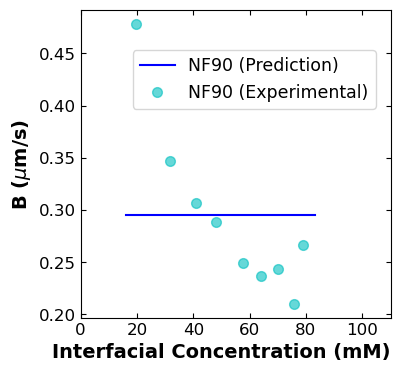

In [47]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s
cIn = []

fig = plt.figure(figsize=(4,4))

x_data_nf90_B_meas = []
y_data_nf90_B_meas = []

# simulated
cIn0 = 16.17231759780746
cInf = 83.16774021880602
B90 = data_stru90['data_config']["B0"]
plt.plot([cIn0,cInf],[B90,B90],'b-',linewidth=1.5)
x_data_nf90_B_predict = [cIn0,cInf]
y_data_nf90_B_predict = [B90,B90]

# experimental
for vial in range(data_stru90['data_config']['n']):
    # calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    # calculate exp R = 1-(cp/cin) per vial
    vial_R_exp = 1 - (data_stru90["data_raw"][vial]['cV_avg'] / cIn_exp)
    # calculate exp B = Jw((1-R)/R) per vial
    vial_B90_exp = vial_water_flux_exp * ((1-vial_R_exp)/vial_R_exp) *10000 #um/s

    plt.plot(cIn_exp,vial_B90_exp,'co',markersize=7, alpha=0.6)
    x_data_nf90_B_meas.append(cIn_exp)
    y_data_nf90_B_meas.append(vial_B90_exp)

    cIn = []

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')

# ghost point for legend    
plt.plot([],[],'b-',linewidth=1.5,label='NF90 (Prediction)')
plt.plot([],[],'co',markersize=7, alpha=0.6,label='NF90 (Experimental)')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(0.98, 0.65))
plt.xlim(left=0,right=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

with open("NAMS_data/x_data_nf90_B_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf90_B_predict)
with open("NAMS_data/y_data_nf90_B_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf90_B_predict)
with open("NAMS_data/x_data_nf90_B_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf90_B_meas)
with open("NAMS_data/y_data_nf90_B_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf90_B_meas)

# NF270 (DATA2)
## Concentrations-Lag: Figure 6A-C

### Parameter estimation with a linear B

In [8]:
import pandas as pd

In [9]:
# this cell only needed if sim_stru_nams270.json not available

# data_stru270 = loadmat('data_library/data_stru-dataset270511.123.mat')['data_stru']
# sim_stru270_list=[]
# mode = 'Lag'
# theta = {'Lp': 11,
#   'beta_c': 15,
#   'beta_0': 1,
#   'beta_1': 0.01,
#   'sigma': 1.0,
#   'S0': 0}
# fit_stru270, sim_stru270_list, sim_inter270 = solve_model(data_stru270, mode, theta, sim_opt=False, B_form=1,LOUD=True)
# sim_stru270_df = pd.DataFrame(sim_stru270_list)
# sim_stru270_df.to_json("sim_stru270_nams")

In [49]:
data_stru270 = loadmat('data_library/data_stru-dataset270511.123.mat')['data_stru']
sim_stru270_dataframe = pd.read_json('NAMS_data/sim_stru270_nams')

sim_stru270_dataframe.head()


Loading data file = data_library/data_stru-dataset270511.123.mat 



,0,1,2,3,4,5,6,7,8,9,10,11,12
time,"[0, 0.116655, 0.233345, 0.35000000000000003, 0...","[35, 35.39996, 35.80004, 36.2, 36.59996, 37.00...","[155, 155.049995, 155.100005, 155.15, 155.1999...","[170, 170.616605, 171.233395, 171.85, 172.4666...","[355, 355.73326, 356.46674, 357.2, 357.93326, ...","[575, 575.783255, 576.566745, 577.35, 578.1332...","[810, 810.86658, 811.73342, 812.6, 813.46658, ...","[1070, 1070.89991, 1071.80009, 1072.7, 1073.59...","[1340, 1340.89991, 1341.80009, 1342.7, 1343.59...","[1610, 1610.883245, 1611.766755, 1612.65, 1613...","[1875, 1875.93324, 1876.86676, 1877.8, 1878.73...","[2155, 2155.916575, 2156.833425, 2157.75, 2158...","[2430, 2430.9999, 2432.0001, 2433.0, 2433.9999..."
cF,"[16.04248521, 16.042492215, 16.04266466, 16.04...","[16.1295186248, 16.1305272776, 16.1315363383, ...","[16.4416172497, 16.4417519467, 16.4418866881, ...","[16.4822182604, 16.5186873941, 16.5551223858, ...","[26.5653866054, 26.6029655975, 26.640539162, 2...","[37.1468430295, 37.1822105556, 37.2175735049, ...","[47.1232482828, 47.1578360711, 47.1924191299, ...","[56.8674965252, 56.8991593354, 56.9308183145, ...","[65.8055634191, 65.8335819654, 65.8615978391, ...","[73.7422877665, 73.7667883935, 73.791287344, 7...","[80.70837617870001, 80.7316106246, 80.75484337...","[87.3097039355, 87.33015391, 87.3506028158, 87...","[93.1366689527, 93.1567757922, 93.176881187, 9..."
cIn,"[21.9283081845, 19.6181999723, 19.0094520299, ...","[18.676987369, 18.6782662223, 18.6795424428, 1...","[19.034684458, 19.0348359541, 19.0349875002, 1...","[19.0803443572, 19.1309006622, 19.1810693405, ...","[30.4659583761, 30.5068290847, 30.5476907034, ...","[41.8621700914, 41.8999241451, 41.9376713134, ...","[52.4396652745, 52.4761083634, 52.5125450372, ...","[62.6545746578, 62.6876107052, 62.7206418291, ...","[71.9461044319, 71.975130809, 72.0041538362, 7...","[80.1464766244, 80.1717273733, 80.1969760258, ...","[87.3117496046, 87.3356034914, 87.3594553571, ...","[94.0782101435, 94.0991393865, 94.1200673456, ...","[100.0343551877, 100.0548831619, 100.075409498..."
cH,"[1e-06, 7.9450277548, 9.5704816358, 10.1142752...","[10.7038754835, 10.7042269459, 10.7045861908, ...","[10.9047655855, 10.9048591988, 10.9049528433, ...","[10.9329909708, 10.9349585777, 10.9377010839, ...","[17.541645381, 17.5696042052, 17.5975634134, 1...","[25.5750830696, 25.6024355077, 25.6297875022, ...","[33.4060182032, 33.4335465433, 33.4610735737, ...","[41.2534840861, 41.2792687113, 41.3050519642, ...","[48.5985066559, 48.621731244, 48.6449548093, 4...","[55.2231530792, 55.2437405717, 55.2643274687, ...","[61.1083720181, 61.1281045801, 61.1478363679, ...","[66.7407150899, 66.7582419606, 66.7757683875, ...","[71.7534157272, 71.7707760274, 71.7881355034, ..."
mV,"[1e-06, 0.0005167641, 0.0010490335, 0.00158669...","[1e-06, 0.0018621227000000001, 0.0037237807, 0...","[1e-06, 0.00023315140000000002, 0.0004653723, ...","[0.06964522050000001, 0.07250587010000001, 0.0...","[1e-06, 0.0031848155000000003, 0.0063689928, 0...","[1e-06, 0.0032368289, 0.0064731178, 0.00970792...","[1e-06, 0.0034318756000000002, 0.0068632961, 0...","[1e-06, 0.0034303106, 0.0068602409, 0.01028873...","[1e-06, 0.0033205340000000004, 0.0066407365, 0...","[1e-06, 0.0031718391, 0.0063433712000000005, 0...","[1e-06, 0.0032764319, 0.0065526052000000005, 0...","[1e-06, 0.0031527898000000003, 0.0063053297, 0...","[1e-06, 0.0033801677, 0.0067601507, 0.01013892..."


In [50]:
sim_stru270 = {}
for vial_num in range(data_stru270['data_config']['n']):
    vial_series = sim_stru270_dataframe[vial_num]
    sim_stru270[vial_num] = vial_series.to_dict()

print(sim_stru270)

{0: {'time': [0, 0.116655, 0.233345, 0.35000000000000003, 0.466655, 0.583345, 0.7000000000000001, 0.8166549999999999, 0.933345, 1.05, 1.166655, 1.283345, 1.4, 1.516655, 1.633345, 1.75, 1.866655, 1.983345, 2.1, 2.216655, 2.333345, 2.45, 2.566655, 2.683345, 2.8, 2.916655, 3.033345, 3.15, 3.266655, 3.383345, 3.5, 3.616655, 3.733345, 3.85, 3.966655, 4.083345, 4.2, 4.316655, 4.433345, 4.55, 4.6666549999999996, 4.783345, 4.9, 5.016655, 5.133345, 5.25, 5.366655, 5.483345, 5.6, 5.716655, 5.833345, 5.95, 6.066655, 6.183345, 6.3, 6.4166549999999996, 6.533345, 6.65, 6.766655, 6.883345, 7.0, 7.116655, 7.233345, 7.35, 7.466655, 7.583345, 7.7, 7.816655, 7.933345, 8.05, 8.166655, 8.283345, 8.4, 8.516655, 8.633345, 8.75, 8.866655, 8.983345, 9.1, 9.216655, 9.333345, 9.45, 9.566655, 9.683345, 9.8, 9.916655, 10.033345, 10.15, 10.266655, 10.383345, 10.5, 10.616655, 10.733345, 10.85, 10.966655, 11.083345, 11.2, 11.316655, 11.433345, 11.55, 11.666655, 11.783345, 11.9, 12.016655, 12.133345, 12.25, 12.366655,

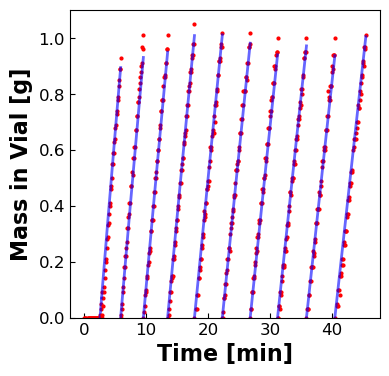

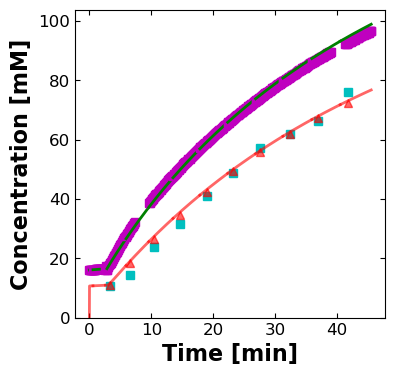

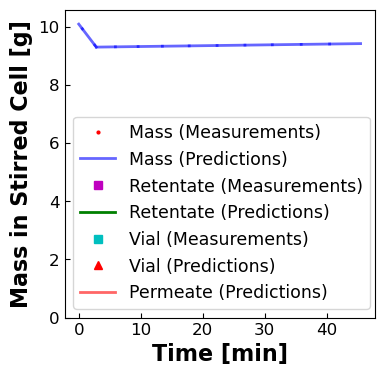

In [51]:
plot_sim_comparison(data_stru270,sim_stru270,stirc_mass=True,plot_pred=True,lg=True,LOUD=True)

100


(-0.12916666666666668, 2.8)

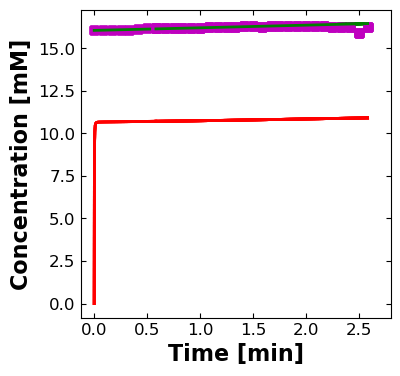

In [13]:
# plot concentration data/prediction comparison
fig,ax = plt.subplots(figsize=(4,4))

t_delay = data_stru270['data_raw'][0]['time'][0]
print(t_delay)
t_start = 0

for i in range(data_stru270['data_config']['n']):
    for pt in range(len((data_stru270['data_raw'][i]['time']))):
        if (data_stru270['data_raw'][i]['time'][pt] <= 200):
            plt.plot([(float(t)-t_delay-t_start)/60 for t in data_stru270['data_raw'][i]['time']],
                        data_stru270['data_raw'][i]['cF_exp'],'ms',markersize=6,clip_on=False)
            plt.plot([(time-t_start)/60 for time in sim_stru270[i]['time']],
                        sim_stru270[i]['cF'],
                        'g',linewidth=2)
            plt.plot([(time-t_start)/60 for time in sim_stru270[i]['time']],
                        sim_stru270[i]['cH'],
                        'r-',linewidth=2,alpha=.6)
            if type(data_stru270['data_raw'][i]['cV_avg']) != list:
                plt.plot((sim_stru270[i]['time'][-1]-t_start)/60,
                            sim_stru270[i]['cV'][-1],
                            'r^',linewidth=2,alpha=.6)
            else:
                time = data_stru270['data_raw'][i]['time']-t_delay
                index = ~np.isnan(data_stru270['data_raw'][i]['cV_avg'])
                t = [time[i] for i, val in enumerate(index) if val]
                f = interpolate.interp1d(sim_stru270[i]['time'],sim_stru270[i]['cV'], fill_value='extrapolate')  
                plt.plot([(ti-t_start)/60 for ti in t],
                            f(t),
                            'r^',linewidth=2,alpha=.6)
            
plt.xlabel('Time [min]',fontsize=16,fontweight='bold')
plt.ylabel('Concentration [mM]',fontsize=16,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)
plt.xlim(right=2.8)

In [52]:
cV_exp_values = [0,0,0]
for vial_dict in data_stru270["data_raw"]:
    for variable, values in vial_dict.items():
        if variable == 'cV_avg':
            for x in values:
                if str(x) != 'nan':
                    cV_exp_values.append(x)
print(cV_exp_values)
print(len(cV_exp_values))

[0, 0, 0, 10.63030414, 14.22108286, 23.72155353, 31.57139223, 40.92372016, 48.77230198, 57.01986578, 61.91865276, 66.15705841, 75.88025664]
13


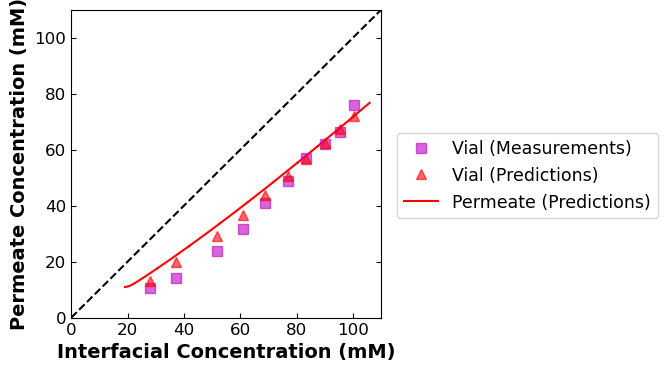

In [56]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)

fig = plt.figure(figsize=(4,4))
x_data_nf270_perm_predict = []
y_data_nf270_perm_predict = []
x_data_nf270_vial_predict = []
y_data_nf270_vial_predict = []
x_data_nf270_vial_meas = []
y_data_nf270_vial_meas = []

for vial in range(data_stru270['data_config']['n']):
    # skip the first three entries
    if vial >= 3:
        # plot permeate predictions
        plt.plot(sim_stru270[vial]["cIn"],sim_stru270[vial]["cH"],'r-',linewidth=1.5)
        for i in sim_stru270[vial]["cIn"]:
            x_data_nf270_perm_predict.append(i)
        for i in sim_stru270[vial]["cH"]:
            y_data_nf270_perm_predict.append(i)

        # calculate exp water flux per vial
        vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
        vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
        # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
        # remove nan from cF_exp
        cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
        cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
        cF_vals = []

        # vial measurements, plot at the bulk cIn,exp
        plt.plot(cIn_exp270, cV_exp_values[vial], 'ms', markersize=7, alpha=0.6)
        x_data_nf270_vial_meas.append(cIn_exp270)
        y_data_nf270_vial_meas.append(cV_exp_values[vial])

        # vial predictions, plot the bulk predicted cV and the same cIn as exp
        f = interpolate.interp1d(sim_stru270[vial]["cIn"], sim_stru270[vial]['cV'])
        plt.plot(cIn_exp270,f(cIn_exp270),'r^',markersize=7, alpha=0.6)
        x_data_nf270_vial_predict.append(cIn_exp270)
        y_data_nf270_vial_predict.append(f(cIn_exp270))

plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'ms',markersize=7,label='Vial (Measurements)',alpha=0.6)
plt.plot([],[],'r^',markersize=7,label='Vial (Predictions)',alpha=0.6)        
plt.plot([],[],'r-',linewidth=1.5,label='Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.6),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in", right=True)

with open("NAMS_data/x_data_nf270_perm_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf270_perm_predict)
with open("NAMS_data/y_data_nf270_perm_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf270_perm_predict)
with open("NAMS_data/x_data_nf270_vial_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf270_vial_predict)
with open("NAMS_data/y_data_nf270_vial_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf270_vial_predict)
with open("NAMS_data/x_data_nf270_vial_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf270_vial_meas)
with open("NAMS_data/y_data_nf270_vial_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf270_vial_meas)

## Solute Permeability

In [42]:
# determine the units of the reported B values
Jw_calc = []
Jw_reported_avg = []
cIn_reported_avg = []
B_reported_avg = []
cIn_sim = []
cIn_sim_avg = []
B_sim_avg = []

for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        # if vial >= 3:
        if vial == 12:
                B_reported = [x for x in sim_stru270[vial]["B"]]# um/s
                B_reported_avg.append(np.average(B_reported))
                Jw_reported = [x for x in sim_stru270[vial]["Jw"]]# cm3/cm2/s
                Jw_reported_avg.append(np.average(Jw_reported))
                cIn_reported = [x for x in sim_stru270[vial]["cIn"]]# mM
                cIn_reported_avg.append(np.average(cIn_reported))

                # calculate simulated water flux
                vial_dmdt_sim270 = (sim_stru270[vial]["mV"][-1] - sim_stru270[vial]["mV"][0]) / (sim_stru270[vial]["time"][-1] - sim_stru270[vial]["time"][0]) # g/s
                vial_water_flux_sim270 = (1/4.1)*vial_dmdt_sim270 # cm3/cm2/s
                Jw_calc.append(vial_water_flux_sim270)

                # calculate simulated cIn
                for value in range(len(sim_stru270[vial]["time"])):
                        cIn_sim.append((sim_stru270[vial]['cF'][value]-sim_stru270[vial]['cH'][value])*np.exp(vial_water_flux_sim270/k)+sim_stru270[vial]['cH'][value])# mM

                cIn_sim_avg.append(np.average(cIn_sim))

                # B_sim_calc = [(vial_water_flux_sim270*10000*(1.064929254383047+0.015171422560448225*cint)) for cint in cIn_sim]
                B_sim_calc = [((1.064929254383047+0.015171422560448225*cint)) for cint in cIn_sim]
                B_sim_avg.append(np.average(B_sim_calc))
                
                print(f"Xinhong's Jw for vial {vial} = {Jw_reported} cm/s")
                print(f"Xinhong's average Jw for vial {vial} = {Jw_reported_avg} cm/s")
                print(f"My Jw for vial {vial} = {Jw_calc}cm/s")
                print("\n")
                print(f"Xinhong's cin for vial {vial} = {cIn_reported} mM")  
                print(f"Xinhong's average cin for vial {vial} = {cIn_reported_avg} mM")              
                print(f"My cIn for vial {vial} = {cIn_sim} mM")
                print(f"My average cIn for vial {vial} = {cIn_sim_avg} mM") 
                print("\n")
                print(f"Xinhong's B for vial {vial} = {B_reported} um/s")
                print(f"My B for vial {vial} = {B_sim_calc} um/s")
                
                Jw_calc = []
                Jw_reported_avg = []
                cin_reported_avg = []
                cIn_sim = []
                cIn_sim_avg = []

Xinhong's Jw for vial 12 = [0.0008243181, 0.0008242697, 0.0008242212, 0.0008241728, 0.0008241245, 0.0008240761, 0.0008240278, 0.0008239795, 0.0008239312, 0.0008238830000000001, 0.0008238348, 0.0008237866000000001, 0.0008237384, 0.0008236903000000001, 0.0008236421, 0.0008235941, 0.0008235460000000001, 0.0008234980000000001, 0.00082345, 0.0008234020000000001, 0.0008233540000000001, 0.0008233061, 0.0008232582000000001, 0.0008232103, 0.0008231625000000001, 0.0008231147, 0.0008230669, 0.0008230191000000001, 0.0008229714000000001, 0.0008229237000000001, 0.0008228760000000001, 0.0008228283, 0.0008227807000000001, 0.0008227331, 0.0008226855, 0.0008226380000000001, 0.0008225904, 0.0008225429, 0.0008224955000000001, 0.000822448, 0.0008224006, 0.0008223532, 0.0008223058, 0.0008222585, 0.0008222111, 0.0008221639, 0.0008221166, 0.0008220694000000001, 0.0008220221, 0.0008219750000000001, 0.0008219278, 0.0008218807, 0.0008218335000000001, 0.0008217865, 0.0008217394000000001, 0.0008216924, 0.000821645

### Experimental B=Jw((1-R)/R)

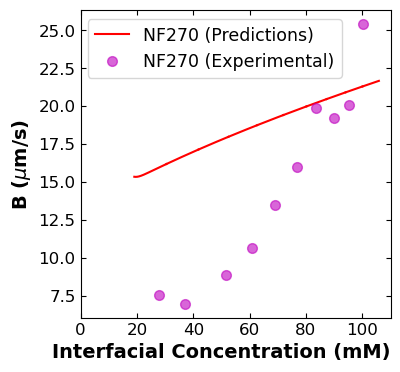

In [70]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s

fig = plt.figure(figsize=(4,4))
B_sim_vals = []

x_data_nf270_B_predict = []
y_data_nf270_B_predict = []
x_data_nf270_B_meas = []
y_data_nf270_B_meas = []

for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        if vial >= 3:
                # simulated
                for value in range(len(sim_stru270[vial]["B"])):
                        B_sim = sim_stru270[vial]["B"][value] * sim_stru270[vial]["Jw"][value] * 10000 # um/s
                        B_sim_vals.append(B_sim)

                plt.plot(sim_stru270[vial]["cIn"],B_sim_vals,'r-',linewidth=1.5)
                for i in sim_stru270[vial]["cIn"]:
                        x_data_nf270_B_predict.append(i)
                for i in B_sim_vals:
                        y_data_nf270_B_predict.append(i)

                # experiental 
                # calculate exp water flux per vial
                vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
                vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
                # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
                # remove nan from cF_exp
                cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
                cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
                cF_vals = []

                # calculate exp R = 1-(cp/cin) per vial
                vial_R_exp270 = 1 - (cV_exp_values[vial] / cIn_exp270)
                # calculate exp B = Jw((1-R)/R) per vial
                vial_B_exp270 = vial_water_flux_exp270 * ((1-vial_R_exp270)/vial_R_exp270) *10000 #um/s

                plt.plot(cIn_exp270,vial_B_exp270,'mo',markersize=7, alpha=0.6)
                x_data_nf270_B_meas.append(cIn_exp270)
                y_data_nf270_B_meas.append(vial_B_exp270)

                B_sim_vals = []

                

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')
plt.xlim(left=0,right=110)

# ghost point for legend    
plt.plot([],[],'r-',linewidth=1.5,label='NF270 (Predictions)')
plt.plot([],[],'mo',markersize=7,alpha=0.6,label='NF270 (Experimental)')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(0.87, 0.75))
plt.xlim(left=0,right=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

with open("NAMS_data/x_data_nf270_B_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf270_B_predict)
with open("NAMS_data/y_data_nf270_B_predict", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf270_B_predict)
with open("NAMS_data/x_data_nf270_B_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(x_data_nf270_B_meas)
with open("NAMS_data/y_data_nf270_B_meas", "w") as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(y_data_nf270_B_meas)

# Combined plots for NF90/NF270
## Concentrations

<Figure size 400x400 with 0 Axes>

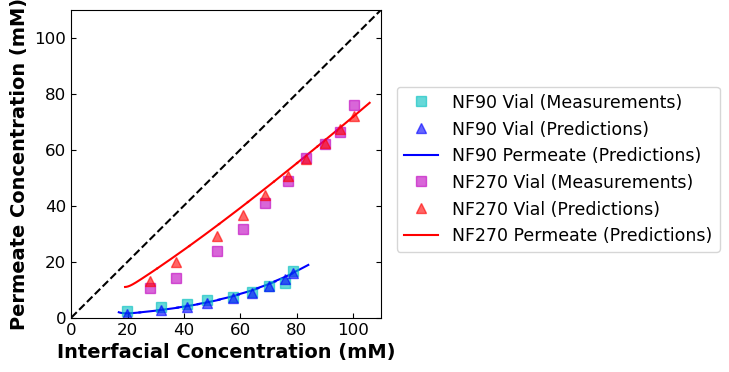

In [22]:
fig = plt.figure(figsize=(4,4))
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)
#-------------------------------------------------------------------------------------------------------------------------------
# NF 90
cIn_sim = []
fig = plt.figure(figsize=(4,4))

for vial in range(data_stru90['data_config']['n']):
    # calculate simulated water flux per vial
    vial_dmdt_sim = (sim_stru90[vial]["mV"][-1] - sim_stru90[vial]["mV"][0]) / (sim_stru90[vial]["time"][-1] - sim_stru90[vial]["time"][0])
    vial_water_flux_sim = (1/4.1)*vial_dmdt_sim # cm3/cm2/s
    # calculate simulated cIn
    for value in range(len(sim_stru90[vial]["time"])):
        cIn_sim.append((sim_stru90[vial]['cF'][value]-sim_stru90[vial]['cH'][value])*np.exp(vial_water_flux_sim/k)+sim_stru90[vial]['cH'][value])

    # calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    
    # permeate predictions
    plt.plot(cIn_sim,sim_stru90[vial]["cH"],'b-',linewidth=1.5)

    # vial measurements, plot at the bulk cIn,exp
    plt.plot(cIn_exp,data_stru90['data_raw'][vial]['cV_avg'],'cs',markersize=7,alpha=0.6)

    # vial predictions, plot the bulk predicted cV and the same cIn as exp
    f = interpolate.interp1d(cIn_sim, sim_stru90[vial]['cV'])
    plt.plot(cIn_exp,f(cIn_exp),'b^',markersize=7, alpha=0.6)
    
    cIn_sim = []
#-------------------------------------------------------------------------------------------------------------------------------
# NF 270
for vial in range(data_stru270['data_config']['n']):
    # skip the first three entries
    if vial >= 3:
        # plot permeate predictions
        plt.plot(sim_stru270[vial]["cIn"],sim_stru270[vial]["cH"],'r-',linewidth=1.5)

        # calculate exp water flux per vial
        vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
        vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
        # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
        # remove nan from cF_exp
        cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
        cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
        cF_vals = []

        # vial measurements, plot at the bulk cIn,exp
        plt.plot(cIn_exp270, cV_exp_values[vial], 'ms', markersize=7, alpha=0.6)

        # vial predictions, plot the bulk predicted cV and the same cIn as exp
        f = interpolate.interp1d(sim_stru270[vial]["cIn"], sim_stru270[vial]['cV'])
        plt.plot(cIn_exp270,f(cIn_exp270),'r^',markersize=7, alpha=0.6)
#-------------------------------------------------------------------------------------------------------------------------------

plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,alpha=0.6,label='NF90 Vial (Measurements)')
plt.plot([],[],'b^',markersize=7,alpha=0.6,label='NF90 Vial (Predictions)')        
plt.plot([],[],'b-',linewidth=1.5,label='NF90 Permeate (Predictions)')
plt.plot([],[],'ms',markersize=7,alpha=0.6,label='NF270 Vial (Measurements)')
plt.plot([],[],'r^',markersize=7,alpha=0.6,label='NF270 Vial (Predictions)')        
plt.plot([],[],'r-',linewidth=1.5,label='NF270 Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.75),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in", right=True)

## Solute Permeability

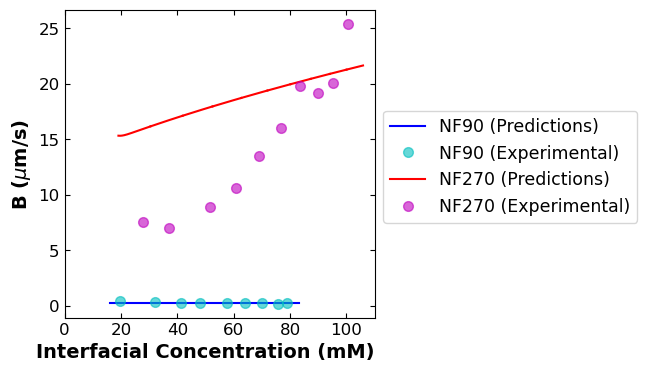

In [69]:
fig = plt.figure(figsize=(4,4))
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s
#-------------------------------------------------------------------------------------------------------------------------------
# NF 90

cIn = []

# simulated
cIn0 = 16.17231759780746
cInf = 83.16774021880602
B90 = data_stru90['data_config']["B0"]
plt.plot([cIn0,cInf],[B90,B90],'b-',linewidth=1.5)

# experimental
for vial in range(data_stru90['data_config']['n']):
    ## calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    # calculate exp R = 1-(cp/cin) per vial
    vial_R_exp = 1 - (data_stru90["data_raw"][vial]['cV_avg'] / cIn_exp)
    # calculate exp B = Jw((1-R)/R) per vial
    vial_B90_exp = vial_water_flux_exp * ((1-vial_R_exp)/vial_R_exp) *10000 #um/s

    plt.plot(cIn_exp,vial_B90_exp,'co',markersize=7, alpha=0.6)

    cIn = []
#-------------------------------------------------------------------------------------------------------------------------------
# NF 270
B_sim_vals = []

for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        if vial >= 3:
                # simulated
                for value in range(len(sim_stru270[vial]["B"])):
                        B_sim = sim_stru270[vial]["B"][value] * sim_stru270[vial]["Jw"][value] * 10000 # um/s
                        B_sim_vals.append(B_sim)

                plt.plot(sim_stru270[vial]["cIn"],B_sim_vals,'r-',linewidth=1.5)

                # experiental 
                # calculate exp water flux per vial
                vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
                vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
                # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
                # remove nan from cF_exp
                cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
                cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
                cF_vals = []

                # calculate exp R = 1-(cp/cin) per vial
                vial_R_exp270 = 1 - (cV_exp_values[vial] / cIn_exp270)
                # calculate exp B = Jw((1-R)/R) per vial
                vial_B_exp270 = vial_water_flux_exp270 * ((1-vial_R_exp270)/vial_R_exp270) *10000 #um/s

                plt.plot(cIn_exp270,vial_B_exp270,'mo',markersize=7, alpha=0.6)

                B_sim_vals = []
#-------------------------------------------------------------------------------------------------------------------------------

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')

# ghost point for legend    
plt.plot([],[],'b-',linewidth=1.5,label='NF90 (Predictions)')
plt.plot([],[],'co',markersize=7, alpha=0.6,label='NF90 (Experimental)')
plt.plot([],[],'r-',linewidth=1.5,label='NF270 (Predictions)')
plt.plot([],[],'mo',markersize=7, alpha=0.6,label='NF270 (Experimental)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1, 0.7))
plt.xlim(left=0,right=110)
# plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

plt.show()